In [ ]:
# Introdução - Long Short Term Memory

# Univariate time series forescasting
import numpy as np
from matplotlib import pyplot
from numpy import sqrt
from numpy import asarray
from numpy import random
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from keras import Sequential
from keras.layers import LSTM, Dense, Input
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split

In [ ]:
# Divide uma sequência em amostras
def split_sequence(sequence, n_steps):
	X, y = list(), list()
	for i in range(len(sequence)):
		# encontra o fim desse padrão
		end_ix = i + n_steps
		# verifica para o tamanho da sequência
		if end_ix > len(sequence)-1:
			break
		# Pega a entrada e saída para esse padrão
		seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return asarray(X), asarray(y)

In [ ]:
# Carrega o conjunto de dados
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
#df = read_csv(path, header=0, index_col=0, squeeze=True)
df = read_csv(path, header=0, index_col=0)

# Pega os valores
values = df.values.astype('float32')
print(values)

[[ 6550.]
 [ 8728.]
 [12026.]
 [14395.]
 [14587.]
 [13791.]
 [ 9498.]
 [ 8251.]
 [ 7049.]
 [ 9545.]
 [ 9364.]
 [ 8456.]
 [ 7237.]
 [ 9374.]
 [11837.]
 [13784.]
 [15926.]
 [13821.]
 [11143.]
 [ 7975.]
 [ 7610.]
 [10015.]
 [12759.]
 [ 8816.]
 [10677.]
 [10947.]
 [15200.]
 [17010.]
 [20900.]
 [16205.]
 [12143.]
 [ 8997.]
 [ 5568.]
 [11474.]
 [12256.]
 [10583.]
 [10862.]
 [10965.]
 [14405.]
 [20379.]
 [20128.]
 [17816.]
 [12268.]
 [ 8642.]
 [ 7962.]
 [13932.]
 [15936.]
 [12628.]
 [12267.]
 [12470.]
 [18944.]
 [21259.]
 [22015.]
 [18581.]
 [15175.]
 [10306.]
 [10792.]
 [14752.]
 [13754.]
 [11738.]
 [12181.]
 [12965.]
 [19990.]
 [23125.]
 [23541.]
 [21247.]
 [15189.]
 [14767.]
 [10895.]
 [17130.]
 [17697.]
 [16611.]
 [12674.]
 [12760.]
 [20249.]
 [22135.]
 [20677.]
 [19933.]
 [15388.]
 [15113.]
 [13401.]
 [16135.]
 [17562.]
 [14720.]
 [12225.]
 [11608.]
 [20985.]
 [19692.]
 [24081.]
 [22114.]
 [14220.]
 [13434.]
 [13598.]
 [17187.]
 [16119.]
 [13713.]
 [13210.]
 [14251.]
 [20139.]
 [21725.]


In [ ]:
# Especifica o tamanho da janela
n_steps = 5

# Divide em amostras
X, y = split_sequence(values, n_steps)
print(X[0:10])
print(y[0:10])
print(X.shape)
print(y.shape)

[[[ 6550.]
  [ 8728.]
  [12026.]
  [14395.]
  [14587.]]

 [[ 8728.]
  [12026.]
  [14395.]
  [14587.]
  [13791.]]

 [[12026.]
  [14395.]
  [14587.]
  [13791.]
  [ 9498.]]

 [[14395.]
  [14587.]
  [13791.]
  [ 9498.]
  [ 8251.]]

 [[14587.]
  [13791.]
  [ 9498.]
  [ 8251.]
  [ 7049.]]

 [[13791.]
  [ 9498.]
  [ 8251.]
  [ 7049.]
  [ 9545.]]

 [[ 9498.]
  [ 8251.]
  [ 7049.]
  [ 9545.]
  [ 9364.]]

 [[ 8251.]
  [ 7049.]
  [ 9545.]
  [ 9364.]
  [ 8456.]]

 [[ 7049.]
  [ 9545.]
  [ 9364.]
  [ 8456.]
  [ 7237.]]

 [[ 9545.]
  [ 9364.]
  [ 8456.]
  [ 7237.]
  [ 9374.]]]
[[13791.]
 [ 9498.]
 [ 8251.]
 [ 7049.]
 [ 9545.]
 [ 9364.]
 [ 8456.]
 [ 7237.]
 [ 9374.]
 [11837.]]
(103, 5, 1)
(103, 1)


In [ ]:
# # Reshape em [samples, timesteps, features]
# X = X.reshape((X.shape[0], X.shape[1], 1))
# print(X[0:5,])
# print(y[0:5])
# print(X.shape)

In [ ]:
# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(72, 5, 1) (31, 5, 1) (72, 1) (31, 1)


In [ ]:
# Criamos dois objetos separados: um para as entradas (X) e outro para as saídas (y).
# Isso é vital porque o X tem várias colunas/passos e o y é apenas o valor alvo.
# Ter um scaler_y exclusivo permite usar o inverse_transform() no futuro para ver os valores reais.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# --- Ajustando as Entradas (X) ---

# Guardamos a quantidade de linhas (amostras) de cada conjunto para não perder a conta no reshape.
n_samples_train = X_train.shape[0]
n_samples_test = X_test.shape[0]

# O StandardScaler espera dados 2D (linhas, colunas), mas o X da LSTM é 3D (amostras, passos, 1).
# 1. .reshape(n_samples, -1): "Achata" os 5 passos no tempo em uma única linha horizontal.
# 2. .fit_transform: O scaler APRENDE a média/desvio do treino e já aplica a normalização.
X_train_scaled = scaler_X.fit_transform(X_train.reshape(n_samples_train, -1))

# 3. .transform: No teste, NÃO usamos fit. Apenas aplicamos a média que foi aprendida no treino.
# Isso garante que o teste seja tratado como "dados novos" e desconhecidos.
X_test_scaled = scaler_X.transform(X_test.reshape(n_samples_test, -1))

# Após a normalização, o dado está em 2D. Precisamos voltar para 3D para a LSTM aceitar.
# Reorganizamos para: (número de amostras, quantidade de passos no tempo, 1 característica).
X_train_scaled = X_train_scaled.reshape(n_samples_train, n_steps, 1)
X_test_scaled = X_test_scaled.reshape(n_samples_test, n_steps, 1)

# --- Ajustando os Alvos (y) ---

# O y geralmente já é 2D ou 1D, mas o Keras prefere (amostras, 1).
# .reshape(-1, 1) garante que o array seja uma coluna vertical, independente do número de linhas.
# Novamente: fit_transform no treino para aprender a escala dos valores.
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)) # -> reshape reduntante. Já é (amostras, 1)

# Apenas transform no teste usando a escala do treino.
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)) # -> reshape reduntante. Já é (amostras, 1)

Modelo adotado:

Entrada

      ↓

LSTM com 50 unidades

     ↓

Dense com 25 neurônios

      ↓

Dense com 1 neurônio

In [ ]:
# Define o modelo
model = Sequential()
model.add(Input(shape=(n_steps, 1)))
model.add(LSTM(50))
#model.add(Dense(50, activation='leaky_relu'))
model.add(Dense(25,activation='leaky_relu'))
model.add(Dense(1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,701 (45.71 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compila o modelo
model.compile(optimizer='adam', loss='mse')

# Treina o modelo
history = model.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - loss: 0.9789 - val_loss: 0.8122
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8863 - val_loss: 0.8210
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8202 - val_loss: 0.8431
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7814 - val_loss: 0.8727
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7657 - val_loss: 0.8907
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7463 - val_loss: 0.8696
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7269 - val_loss: 0.8529
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7147 - val_loss: 0.8261
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6978 - val_loss: 0.8178
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6844 - val_loss: 0.8029
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6714 - val_loss: 0.7899
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.6623 - val_l

In [ ]:
# Plota a curva de aprendizado
def plot_learning_curve():
  pyplot.title('Learning Curves')
  pyplot.xlabel('Epoch')
  pyplot.ylabel('Error')
  pyplot.plot(history.history['loss'], label='train')
  pyplot.plot(history.history['val_loss'], label='val')
  pyplot.legend()
  pyplot.show()

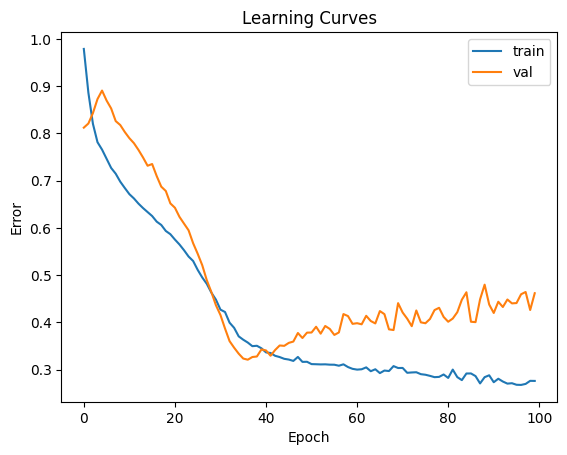

In [ ]:
plot_learning_curve()

In [ ]:
# Avalia o modelo
mse = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print('MSE: %.3f, RMSE: %.3f' % (mse, sqrt(mse)))

MSE: 0.365, RMSE: 0.604


In [ ]:
# Vamos ver as predições
predictions_scaled = model.predict(X_test_scaled)
print(predictions_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
[[ 1.8175883 ]
 [ 0.12522464]
 [ 1.3699551 ]
 [ 1.46215   ]
 [-0.33314633]
 [-1.5036165 ]
 [ 0.21296613]
 [-0.78414494]
 [-0.915698  ]
 [ 0.04589165]
 [-0.94934255]
 [ 1.4722828 ]
 [-0.00455881]
 [ 0.122449  ]
 [-0.6954374 ]
 [-1.4663887 ]
 [ 0.3240489 ]
 [ 1.0976062 ]
 [-0.07198747]
 [ 1.6951967 ]
 [ 0.90546757]
 [-0.15419902]
 [-0.8643905 ]
 [-0.7995955 ]
 [-0.48085085]
 [-1.0547597 ]
 [-1.4838506 ]
 [-0.12726946]
 [-0.51844794]
 [-0.03595109]
 [-0.65408623]]


In [ ]:
# Desfaz a escala usando o scaler do 'y'
predictions_original = scaler_y.inverse_transform(predictions_scaled)

In [ ]:
# Compara predições com valores verdadeiros
y_test_original = scaler_y.inverse_transform(y_test_scaled)

print(np.hstack((y_test_original, predictions_original)))

[[20677.     23565.568 ]
 [10895.     15815.267 ]
 [20128.     21515.6   ]
 [16205.     21937.814 ]
 [10792.     13716.124 ]
 [ 8997.      8355.871 ]
 [15113.     16217.086 ]
 [15175.     11650.743 ]
 [10862.     11048.286 ]
 [18024.     15451.956 ]
 [ 7048.9995 10894.209 ]
 [19692.     21984.217 ]
 [14767.     15220.914 ]
 [14220.     15802.556 ]
 [10947.     12056.985 ]
 [ 9374.      8526.358 ]
 [13401.     16725.797 ]
 [17816.     20268.36  ]
 [10306.     14912.12  ]
 [22015.     23005.068 ]
 [17180.     19388.445 ]
 [19990.     14535.626 ]
 [ 9364.     11283.253 ]
 [10965.     11579.986 ]
 [ 9498.     13039.7   ]
 [11474.     10411.443 ]
 [ 8251.      8446.391 ]
 [11738.     14658.952 ]
 [10583.     12867.521 ]
 [12674.     15077.151 ]
 [14405.     12246.356 ]]
